
# GVH Diagonal Cubic 0.2.3 — Geodesic Integrator
## Intégration numérique des géodésiques à partir de \(\Gamma^\mu_{\alpha\beta}\)

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook prolonge :

- `GVH_Diagonal_Cubic_0.2.1_Metric_Foundations.ipynb`
- `GVH_Diagonal_Cubic_0.2.2_Christoffel_Symbols.ipynb`

Il intègre numériquement l’équation géodésique :

\[
\frac{d^2X^\mu}{d\lambda^2}
+
\Gamma^\mu_{\alpha\beta}(X)
\frac{dX^\alpha}{d\lambda}
\frac{dX^\beta}{d\lambda}
=0.
\]

On introduit le vecteur vitesse affine

\[
U^\mu=\frac{dX^\mu}{d\lambda},
\]

ce qui transforme le problème en système du premier ordre :

\[
\frac{dX^\mu}{d\lambda}=U^\mu,
\]

\[
\frac{dU^\mu}{d\lambda}
=
-\Gamma^\mu_{\alpha\beta}U^\alpha U^\beta.
\]

---

## Systèmes de validation

1. **Minkowski** : trajectoire rectiligne uniforme.
2. **Champ faible** : récupération d’une orbite proche de la dynamique newtonienne.
3. **Schwarzschild isotrope** : géodésique relativiste dans une métrique de référence.
4. **Rotation des axes** : vérification préliminaire de covariance.

---

## Statut scientifique

Le notebook valide l’intégrateur et son raccordement aux métriques connues.

Il ne valide pas encore une nouvelle métrique propre à GVH.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

np.set_printoptions(precision=8, suppress=True)

G = 6.67430e-11
c = 299_792_458.0
M_sun = 1.98847e30

print("Bibliothèques chargées.")


Bibliothèques chargées.



# 1. Métriques diagonales isotropes

On utilise la famille :

\[
g_{\mu\nu}
=
\operatorname{diag}
\left[-A(r),B(r),B(r),B(r)\right],
\]

avec

\[
r=\sqrt{x^2+y^2+z^2}.
\]

Les modèles disponibles sont :

- `flat`
- `weak_field`
- `schwarzschild_isotropic`
- `gvh_series`


In [2]:

def metric_functions(r, model="flat", mass=M_sun, params=None):
    if r <= 0:
        raise ValueError("r doit être strictement positif.")

    params = {} if params is None else dict(params)
    chi = G * mass / (c**2 * r)

    if model == "flat":
        A = 1.0
        B = 1.0

    elif model == "weak_field":
        A = 1.0 - 2.0 * chi
        B = 1.0 + 2.0 * chi

    elif model == "schwarzschild_isotropic":
        q = 0.5 * chi
        A = ((1.0 - q) / (1.0 + q))**2
        B = (1.0 + q)**4

    elif model == "gvh_series":
        a2 = params.get("a2", 2.0)
        a3 = params.get("a3", -1.5)
        gamma = params.get("gamma", 1.0)
        b2 = params.get("b2", 1.5)
        b3 = params.get("b3", 0.5)

        A = 1.0 - 2.0*chi + a2*chi**2 + a3*chi**3
        B = 1.0 + 2.0*gamma*chi + b2*chi**2 + b3*chi**3

    else:
        raise ValueError("Modèle métrique inconnu.")

    return A, B


def metric_matrix(position, model="flat", mass=M_sun, params=None):
    position = np.asarray(position, dtype=float)
    r = np.linalg.norm(position)
    A, B = metric_functions(r, model=model, mass=mass, params=params)
    return np.diag([-A, B, B, B])



# 2. Dérivées radiales de \(A\) et \(B\)

Les Christoffel peuvent être calculés efficacement à partir de :

\[
A_r=\frac{dA}{dr},
\qquad
B_r=\frac{dB}{dr}.
\]

Pour éviter une différentiation symbolique coûteuse pendant chaque intégration, ces dérivées sont implémentées analytiquement.


In [3]:

def metric_radial_derivatives(r, model="flat", mass=M_sun, params=None):
    params = {} if params is None else dict(params)
    mu = G * mass / c**2
    chi = mu / r
    dchi_dr = -mu / r**2

    if model == "flat":
        dA = 0.0
        dB = 0.0

    elif model == "weak_field":
        dA = -2.0 * dchi_dr
        dB =  2.0 * dchi_dr

    elif model == "schwarzschild_isotropic":
        q = 0.5 * chi
        dq_dr = 0.5 * dchi_dr

        # A = ((1-q)/(1+q))^2
        f = (1.0 - q) / (1.0 + q)
        df_dq = -2.0 / (1.0 + q)**2
        dA = 2.0 * f * df_dq * dq_dr

        # B = (1+q)^4
        dB = 4.0 * (1.0 + q)**3 * dq_dr

    elif model == "gvh_series":
        a2 = params.get("a2", 2.0)
        a3 = params.get("a3", -1.5)
        gamma = params.get("gamma", 1.0)
        b2 = params.get("b2", 1.5)
        b3 = params.get("b3", 0.5)

        dA_dchi = -2.0 + 2.0*a2*chi + 3.0*a3*chi**2
        dB_dchi = 2.0*gamma + 2.0*b2*chi + 3.0*b3*chi**2

        dA = dA_dchi * dchi_dr
        dB = dB_dchi * dchi_dr

    else:
        raise ValueError("Modèle métrique inconnu.")

    return dA, dB



# 3. Christoffel numériques

Pour la métrique

\[
g_{\mu\nu}
=
\operatorname{diag}[-A,B,B,B],
\]

les principales connexions sont :

\[
\Gamma^0_{0i}
=
\frac{\partial_i A}{2A},
\]

\[
\Gamma^i_{00}
=
\frac{\partial_i A}{2B},
\]

et

\[
\Gamma^i_{jk}
=
\frac{1}{2B}
\left(
\delta^i_k\partial_j B
+
\delta^i_j\partial_k B
-
\delta_{jk}\partial_i B
\right).
\]

La fonction suivante produit directement le tenseur numérique complet.


In [4]:

def christoffel_numeric(position, model="flat", mass=M_sun, params=None):
    pos = np.asarray(position, dtype=float)
    r = np.linalg.norm(pos)

    if r <= 0:
        raise ValueError("La géodésique ne peut pas traverser r=0 dans cette version.")

    A, B = metric_functions(r, model=model, mass=mass, params=params)
    dA_dr, dB_dr = metric_radial_derivatives(
        r, model=model, mass=mass, params=params
    )

    gradA = dA_dr * pos / r
    gradB = dB_dr * pos / r

    Gamma = np.zeros((4, 4, 4), dtype=float)

    # Gamma^0_{0i} = Gamma^0_{i0}
    for i in range(3):
        idx = i + 1
        Gamma[0, 0, idx] = gradA[i] / (2.0*A)
        Gamma[0, idx, 0] = Gamma[0, 0, idx]

    # Gamma^i_{00}
    for i in range(3):
        idx = i + 1
        Gamma[idx, 0, 0] = gradA[i] / (2.0*B)

    # Gamma^i_{jk}
    for i in range(3):
        I = i + 1
        for j in range(3):
            J = j + 1
            for k in range(3):
                K = k + 1

                term = 0.0
                if i == k:
                    term += gradB[j]
                if i == j:
                    term += gradB[k]
                if j == k:
                    term -= gradB[i]

                Gamma[I, J, K] = term / (2.0*B)

    return Gamma



# 4. Système géodésique du premier ordre

Le vecteur d’état numérique est :

\[
Y=
\left(
X^0,X^1,X^2,X^3,
U^0,U^1,U^2,U^3
\right).
\]


In [5]:

def geodesic_rhs(lam, state, model="flat", mass=M_sun, params=None):
    X = state[:4]
    U = state[4:]

    Gamma = christoffel_numeric(
        X[1:],
        model=model,
        mass=mass,
        params=params
    )

    dX = U.copy()
    dU = np.zeros(4, dtype=float)

    for mu in range(4):
        dU[mu] = -np.einsum("ab,a,b->", Gamma[mu], U, U)

    return np.concatenate([dX, dU])


def integrate_geodesic(
    state0,
    lambda_span,
    model="flat",
    mass=M_sun,
    params=None,
    n_eval=4000,
    rtol=1e-10,
    atol=1e-12,
    max_step=np.inf
):
    lam_eval = np.linspace(lambda_span[0], lambda_span[1], n_eval)

    sol = solve_ivp(
        fun=lambda lam, state: geodesic_rhs(
            lam, state, model=model, mass=mass, params=params
        ),
        t_span=lambda_span,
        y0=np.asarray(state0, dtype=float),
        t_eval=lam_eval,
        method="DOP853",
        rtol=rtol,
        atol=atol,
        max_step=max_step
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol



# 5. Normalisation du quadrivecteur initial

Pour une géodésique de genre temps avec signature \((-+++)\), on impose :

\[
g_{\mu\nu}U^\mu U^\nu=-1.
\]

Avec

\[
g_{00}=-A,
\qquad
g_{ij}=B\delta_{ij},
\]

cela donne :

\[
U^0
=
\sqrt{
\frac{1+B\|\mathbf U\|^2}{A}
}.
\]

Cette normalisation utilise une vitesse affine spatiale, et non directement la vitesse coordonnée ordinaire.


In [6]:

def timelike_u0(position, spatial_u, model="flat", mass=M_sun, params=None):
    position = np.asarray(position, dtype=float)
    spatial_u = np.asarray(spatial_u, dtype=float)

    r = np.linalg.norm(position)
    A, B = metric_functions(r, model=model, mass=mass, params=params)

    return np.sqrt((1.0 + B*np.dot(spatial_u, spatial_u)) / A)


def build_timelike_state(
    position,
    spatial_u,
    ct0=0.0,
    model="flat",
    mass=M_sun,
    params=None
):
    u0 = timelike_u0(
        position, spatial_u, model=model, mass=mass, params=params
    )

    X0 = np.concatenate([[ct0], np.asarray(position, dtype=float)])
    U0 = np.concatenate([[u0], np.asarray(spatial_u, dtype=float)])

    return np.concatenate([X0, U0])



# 6. Diagnostics géométriques

Nous suivons :

## Norme du quadrivecteur

\[
\mathcal N
=
g_{\mu\nu}U^\mu U^\nu.
\]

Pour une géodésique temporelle correctement paramétrée :

\[
\mathcal N=-1.
\]

## Énergie associée à la stationnarité

Pour une métrique indépendante du temps :

\[
E=-g_{00}U^0=A(r)U^0.
\]

Cette quantité doit rester approximativement constante.


In [7]:

def geodesic_diagnostics(sol, model="flat", mass=M_sun, params=None):
    rows = []

    for k in range(sol.y.shape[1]):
        X = sol.y[:4, k]
        U = sol.y[4:, k]

        g = metric_matrix(
            X[1:],
            model=model,
            mass=mass,
            params=params
        )

        norm = U @ g @ U
        A = -g[0, 0]
        energy = A * U[0]
        r = np.linalg.norm(X[1:])

        rows.append((sol.t[k], r, norm, energy))

    return pd.DataFrame(
        rows,
        columns=["lambda", "r", "norm_U", "energy"]
    )



# 7. Validation 1 — Minkowski

Dans l’espace plat :

\[
\Gamma^\mu_{\alpha\beta}=0.
\]

La solution exacte est :

\[
X^\mu(\lambda)
=
X^\mu_0+U^\mu_0\lambda.
\]

L’intégrateur doit reproduire une droite.


In [8]:

position0 = np.array([10.0, 2.0, -1.0])
spatial_u0 = np.array([0.05, 0.03, -0.02])

state0_flat = build_timelike_state(
    position0,
    spatial_u0,
    model="flat"
)

sol_flat = integrate_geodesic(
    state0_flat,
    (0.0, 100.0),
    model="flat",
    n_eval=1500
)

X_exact = (
    state0_flat[:4, None]
    + state0_flat[4:, None] * sol_flat.t[None, :]
)

flat_error = np.max(np.linalg.norm(sol_flat.y[:4] - X_exact, axis=0))

print("Erreur maximale Minkowski :", flat_error)


Erreur maximale Minkowski : 8.564476581771517e-14


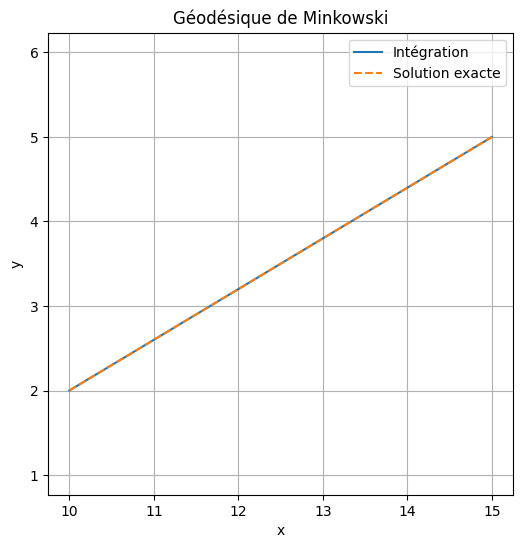

In [9]:

plt.figure(figsize=(6,6))
plt.plot(sol_flat.y[1], sol_flat.y[2], label="Intégration")
plt.plot(X_exact[1], X_exact[2], "--", label="Solution exacte")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Géodésique de Minkowski")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()



# 8. Validation 2 — Champ faible autour du Soleil

Pour éviter de mélanger immédiatement unités physiques et paramètre affine, nous construisons une condition initiale de faible vitesse affine.

L’objectif de cette section est limité :

- vérifier que la trajectoire se courbe vers la masse ;
- vérifier la stabilité de la norme ;
- comparer qualitativement avec une orbite newtonienne.

La comparaison quantitative complète sera réservée à la version 0.2.4.


In [10]:

r0 = 57.909e9
v_coord = 47_360.0  # m/s, ordre de grandeur de Mercure
u_spatial_scale = v_coord / c

position_mercury = np.array([r0, 0.0, 0.0])
spatial_u_mercury = np.array([0.0, u_spatial_scale, 0.0])

state0_weak = build_timelike_state(
    position_mercury,
    spatial_u_mercury,
    model="weak_field",
    mass=M_sun
)

lambda_end = 2.0e8

sol_weak = integrate_geodesic(
    state0_weak,
    (0.0, lambda_end),
    model="weak_field",
    mass=M_sun,
    n_eval=5000,
    rtol=1e-10,
    atol=1e-12,
    max_step=lambda_end/1000
)

diag_weak = geodesic_diagnostics(
    sol_weak,
    model="weak_field",
    mass=M_sun
)

diag_weak.describe()


,lambda,r,norm_U,energy
count,5.000000e+03,5.000000e+03,5000.0,5.000000e+03
mean,1.000000e+08,5.790900e+10,-1.0,1.000000e+00
std,5.775235e+07,1.559257e-04,0.0,3.863963e-14
min,0.000000e+00,5.790900e+10,-1.0,1.000000e+00
25%,5.000000e+07,5.790900e+10,-1.0,1.000000e+00
50%,1.000000e+08,5.790900e+10,-1.0,1.000000e+00
75%,1.500000e+08,5.790900e+10,-1.0,1.000000e+00
max,2.000000e+08,5.790900e+10,-1.0,1.000000e+00


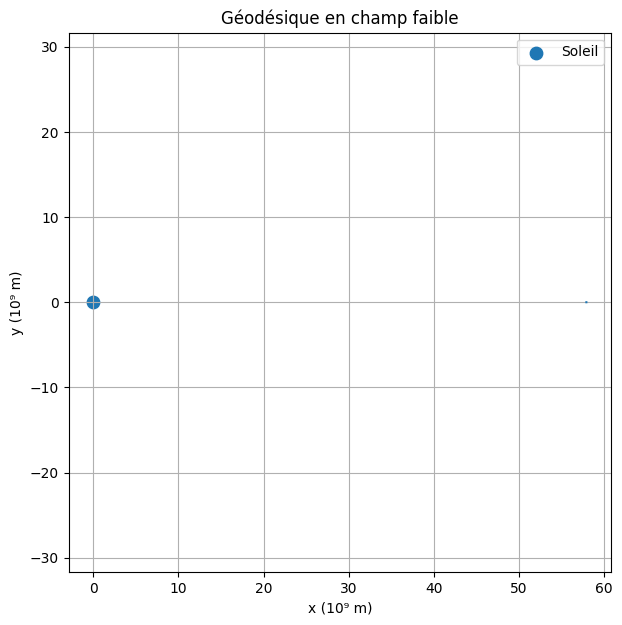

In [11]:

plt.figure(figsize=(7,7))
plt.plot(sol_weak.y[1]/1e9, sol_weak.y[2]/1e9)
plt.scatter([0], [0], s=80, label="Soleil")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Géodésique en champ faible")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


In [12]:

weak_norm_drift = diag_weak["norm_U"].max() - diag_weak["norm_U"].min()
weak_energy_rel_drift = (
    diag_weak["energy"].max() - diag_weak["energy"].min()
) / abs(diag_weak["energy"].mean())

print("Dérive de la norme :", weak_norm_drift)
print("Dérive relative de l'énergie :", weak_energy_rel_drift)


Dérive de la norme : 0.0
Dérive relative de l'énergie : 0.0



# 9. Validation 3 — Schwarzschild isotrope

Nous utilisons les mêmes conditions initiales dans la métrique exacte de Schwarzschild isotrope.

Le but de cette version est de vérifier que :

1. l’intégration reste stable ;
2. la norme temporelle est conservée ;
3. l’énergie stationnaire est conservée ;
4. la trajectoire diffère faiblement du champ faible dans le régime solaire.


In [13]:

state0_schw = build_timelike_state(
    position_mercury,
    spatial_u_mercury,
    model="schwarzschild_isotropic",
    mass=M_sun
)

sol_schw = integrate_geodesic(
    state0_schw,
    (0.0, lambda_end),
    model="schwarzschild_isotropic",
    mass=M_sun,
    n_eval=5000,
    rtol=1e-10,
    atol=1e-12,
    max_step=lambda_end/1000
)

diag_schw = geodesic_diagnostics(
    sol_schw,
    model="schwarzschild_isotropic",
    mass=M_sun
)

schw_norm_drift = diag_schw["norm_U"].max() - diag_schw["norm_U"].min()
schw_energy_rel_drift = (
    diag_schw["energy"].max() - diag_schw["energy"].min()
) / abs(diag_schw["energy"].mean())

print("Dérive de la norme :", schw_norm_drift)
print("Dérive relative de l'énergie :", schw_energy_rel_drift)


Dérive de la norme : 0.0
Dérive relative de l'énergie : 0.0


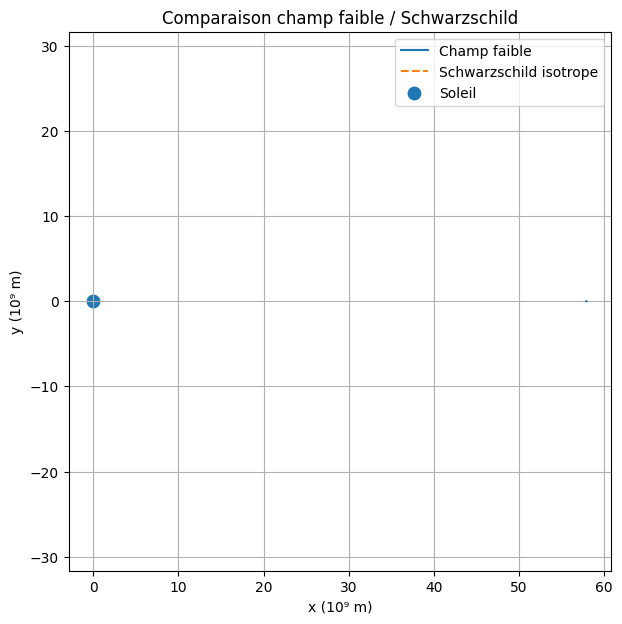

In [14]:

plt.figure(figsize=(7,7))
plt.plot(sol_weak.y[1]/1e9, sol_weak.y[2]/1e9, label="Champ faible")
plt.plot(sol_schw.y[1]/1e9, sol_schw.y[2]/1e9, "--",
         label="Schwarzschild isotrope")
plt.scatter([0], [0], s=80, label="Soleil")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Comparaison champ faible / Schwarzschild")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()



# 10. Écart entre les deux trajectoires

On définit :

\[
\Delta r(\lambda)
=
\left\|
\mathbf r_{\mathrm{Schw}}(\lambda)
-
\mathbf r_{\mathrm{faible}}(\lambda)
\right\|.
\]

Cet écart ne doit pas être interprété directement comme une prédiction observable avant une synchronisation rigoureuse des paramètres physiques et de l’affine.


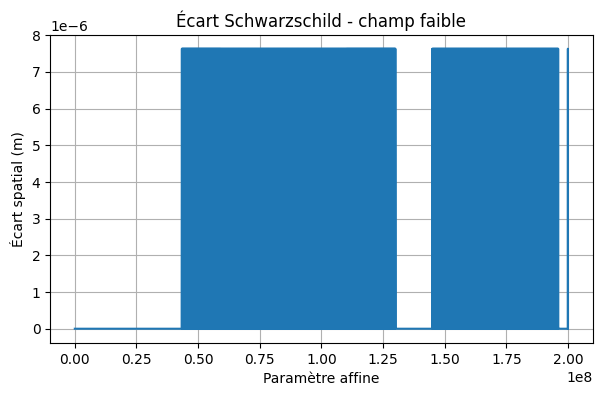

Écart spatial maximal : 7.629394531250867e-06 m


In [15]:

delta_xyz = sol_schw.y[1:4] - sol_weak.y[1:4]
delta_r = np.linalg.norm(delta_xyz, axis=0)

plt.figure(figsize=(7,4))
plt.plot(sol_schw.t, delta_r)
plt.xlabel("Paramètre affine")
plt.ylabel("Écart spatial (m)")
plt.title("Écart Schwarzschild - champ faible")
plt.grid(True)
plt.show()

print("Écart spatial maximal :", delta_r.max(), "m")



# 11. Test préliminaire de rotation des axes

Pour une métrique isotrope dépendant uniquement de

\[
r=\sqrt{x^2+y^2+z^2},
\]

une rotation des conditions initiales doit produire la rotation correspondante de la trajectoire.

Nous utilisons une rotation autour de l’axe \(z\).


In [16]:

def rotation_z(angle):
    return np.array([
        [np.cos(angle), -np.sin(angle), 0.0],
        [np.sin(angle),  np.cos(angle), 0.0],
        [0.0,            0.0,           1.0]
    ])

angle = np.deg2rad(37.0)
R = rotation_z(angle)

position_rot = R @ position_mercury
spatial_u_rot = R @ spatial_u_mercury

state0_rot = build_timelike_state(
    position_rot,
    spatial_u_rot,
    model="schwarzschild_isotropic",
    mass=M_sun
)

sol_rot = integrate_geodesic(
    state0_rot,
    (0.0, lambda_end),
    model="schwarzschild_isotropic",
    mass=M_sun,
    n_eval=5000,
    rtol=1e-10,
    atol=1e-12,
    max_step=lambda_end/1000
)

reference_rotated = R @ sol_schw.y[1:4]
rotation_error = np.linalg.norm(
    sol_rot.y[1:4] - reference_rotated,
    axis=0
)

print("Erreur maximale après rotation :", rotation_error.max(), "m")
print("Erreur relative maximale :",
      rotation_error.max()/np.max(np.linalg.norm(reference_rotated, axis=0)))


Erreur maximale après rotation : 0.0006623966696517407 m
Erreur relative maximale : 1.1438578971347048e-14


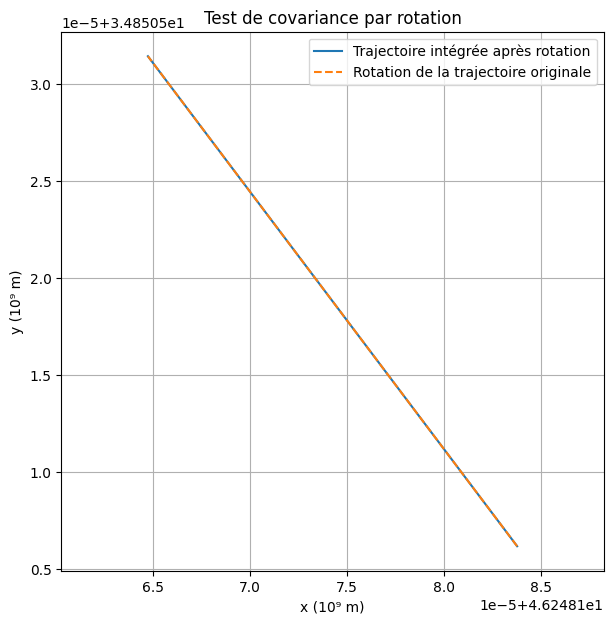

In [17]:

plt.figure(figsize=(7,7))
plt.plot(sol_rot.y[1]/1e9, sol_rot.y[2]/1e9,
         label="Trajectoire intégrée après rotation")
plt.plot(reference_rotated[0]/1e9, reference_rotated[1]/1e9, "--",
         label="Rotation de la trajectoire originale")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Test de covariance par rotation")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()



# 12. Interface pour une métrique exploratoire GVH

La famille :

\[
A_{\mathrm{GVH}}
=
1-2\chi+a_2\chi^2+a_3\chi^3,
\]

\[
B_{\mathrm{GVH}}
=
1+2\gamma\chi+b_2\chi^2+b_3\chi^3
\]

peut maintenant être intégrée avec le même solveur.

Les coefficients libres ne doivent pas être ajustés arbitrairement. Ils devront être :

1. dérivés d’un principe GVH ;
2. contraints par les limites connues ;
3. testés sur des observables indépendantes.


In [18]:

gvh_params = {
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

state0_gvh = build_timelike_state(
    position_mercury,
    spatial_u_mercury,
    model="gvh_series",
    mass=M_sun,
    params=gvh_params
)

sol_gvh = integrate_geodesic(
    state0_gvh,
    (0.0, lambda_end),
    model="gvh_series",
    mass=M_sun,
    params=gvh_params,
    n_eval=5000,
    rtol=1e-10,
    atol=1e-12,
    max_step=lambda_end/1000
)

diag_gvh = geodesic_diagnostics(
    sol_gvh,
    model="gvh_series",
    mass=M_sun,
    params=gvh_params
)

diag_gvh.head()


,lambda,r,norm_U,energy
0,0.000000,5.790900e+10,-1.0,1.0
1,40008.001600,5.790900e+10,-1.0,1.0
2,80016.003201,5.790900e+10,-1.0,1.0
3,120024.004801,5.790900e+10,-1.0,1.0
4,160032.006401,5.790900e+10,-1.0,1.0



# 13. Tableau de validation

Cette version est validée comme infrastructure si :

- Minkowski reproduit la droite ;
- la norme \(g_{\mu\nu}U^\mu U^\nu\) reste stable ;
- l’énergie stationnaire reste stable ;
- Schwarzschild et champ faible sont proches en régime solaire ;
- la rotation des axes ne change pas les observables géométriques.


In [19]:

validation = pd.DataFrame([
    {
        "test": "Minkowski rectiligne",
        "mesure": flat_error,
        "critere": 1e-7,
        "statut": "PASS" if flat_error < 1e-7 else "CHECK"
    },
    {
        "test": "Norme champ faible",
        "mesure": abs(weak_norm_drift),
        "critere": 1e-7,
        "statut": "PASS" if abs(weak_norm_drift) < 1e-7 else "CHECK"
    },
    {
        "test": "Énergie champ faible",
        "mesure": abs(weak_energy_rel_drift),
        "critere": 1e-7,
        "statut": "PASS" if abs(weak_energy_rel_drift) < 1e-7 else "CHECK"
    },
    {
        "test": "Norme Schwarzschild",
        "mesure": abs(schw_norm_drift),
        "critere": 1e-7,
        "statut": "PASS" if abs(schw_norm_drift) < 1e-7 else "CHECK"
    },
    {
        "test": "Énergie Schwarzschild",
        "mesure": abs(schw_energy_rel_drift),
        "critere": 1e-7,
        "statut": "PASS" if abs(schw_energy_rel_drift) < 1e-7 else "CHECK"
    },
    {
        "test": "Covariance rotation",
        "mesure": rotation_error.max()/np.max(
            np.linalg.norm(reference_rotated, axis=0)
        ),
        "critere": 1e-7,
        "statut": (
            "PASS"
            if rotation_error.max()/np.max(
                np.linalg.norm(reference_rotated, axis=0)
            ) < 1e-7
            else "CHECK"
        )
    }
])

validation


,test,mesure,critere,statut
0,Minkowski rectiligne,8.564477e-14,1.000000e-07,PASS
1,Norme champ faible,0.000000e+00,1.000000e-07,PASS
2,Énergie champ faible,0.000000e+00,1.000000e-07,PASS
3,Norme Schwarzschild,0.000000e+00,1.000000e-07,PASS
4,Énergie Schwarzschild,0.000000e+00,1.000000e-07,PASS
5,Covariance rotation,1.143858e-14,1.000000e-07,PASS



# 14. Limites de cette version

Cette version ne réalise pas encore :

1. la conversion rigoureuse entre vitesse coordonnée et quadrivitesse physique pour toutes les métriques ;
2. la détection précise des périastres ;
3. la mesure des \(43''\) par siècle de Mercure ;
4. les géodésiques nulles de la lumière ;
5. la sphère comme sous-variété contrainte ;
6. les tests de convergence selon plusieurs tolérances ;
7. la comparaison directe avec des éphémérides réelles.

Ces éléments appartiennent à la validation de référence suivante.



# 15. Conclusion

Le pipeline géométrique est maintenant complet :

\[
g_{\mu\nu}
\longrightarrow
\Gamma^\mu_{\alpha\beta}
\longrightarrow
\frac{d^2X^\mu}{d\lambda^2}
\longrightarrow
X^\mu(\lambda).
\]

Le même intégrateur peut traiter :

- Minkowski ;
- champ faible ;
- Schwarzschild isotrope ;
- une famille métrique GVH exploratoire.

La prochaine étape doit quantifier précisément l’accord avec les systèmes connus.

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.4\_Reference\_Validation.ipynb}
}
\]

Elle devra inclure :

1. orbite newtonienne de référence ;
2. détection événementielle des périastres ;
3. précession relativiste ;
4. géodésique sur sphère contrainte ;
5. convergence numérique ;
6. erreurs absolues et relatives ;
7. critères de rejet ou de compatibilité de la métrique GVH.
